### Libraries

In [1]:
# Set PYTHONHASHSEED environment variable for reproducibility
import os
os.environ['PYTHONHASHSEED'] = '42'

In [2]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

In [3]:
from datasets import Dataset
from transformers import BertTokenizer, TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import set_seed
from transformers import EarlyStoppingCallback

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, accuracy_score
import evaluate

### Setup

In [5]:
# Set path for data
data_path = "../modeldata"

Choose between 2 different sets of data with different ratios

In [6]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train70.csv")
val_df = pd.read_csv(f"{data_path}/val15.csv")
test_df = pd.read_csv(f"{data_path}/test15.csv")

ratio = "70:15:15"

In [7]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train80.csv")
val_df = pd.read_csv(f"{data_path}/val10.csv")
test_df = pd.read_csv(f"{data_path}/test10.csv")

ratio = "80:10:10"

In [8]:
# Ratio used
print(f"Data split ratio: {ratio}")

Data split ratio: 80:10:10


Once a set has been chosen, continue with next steps

In [9]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [10]:
# Convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [11]:
# Set all random seeds
SEED = 42

# Set Python's built-in random seed
import random
random.seed(SEED)

# Set NumPy seed
np.random.seed(SEED)

# Set PyTorch seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set transformers seed for reproducibility
set_seed(SEED)

# Ensure deterministic behavior (especially important for reproducibility on GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Use deterministic algorithms in PyTorch
torch.use_deterministic_algorithms(True)

# Set environment variable for additional determinism
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'  # or ':4294967296:8' for more memory

In [12]:
# Fixes the [WinError 3] by explicitly setting a local cache directory
cache_dir = "../huggingface_cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Tell Hugging Face to use this directory
os.environ['HF_HOME'] = cache_dir

# This turns off the annoying symlink warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

### Tokenization

In [13]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [14]:
# Initiate with the cache path
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', cache_dir=cache_dir)

In [ ]:
# Pass tokenizer as an argument to the function
def preprocess_function(examples, tokenizer):
    return tokenizer(examples["verse"], truncation=True, padding="max_length", max_length=512)

# Tokenize the datasets
tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True, num_proc=1, fn_kwargs={'tokenizer': tokenizer})
tokenized_val_dataset = val_dataset.map(preprocess_function, batched=True, num_proc=1, fn_kwargs={'tokenizer': tokenizer})
tokenized_test_dataset = test_dataset.map(preprocess_function, batched=True, num_proc=1, fn_kwargs={'tokenizer': tokenizer})

Map (num_proc=1): 100%|██████████| 2288/2288 [00:10<00:00, 224.44 examples/s]


In [16]:
print(tokenized_train_dataset)
print(tokenized_val_dataset)
print(tokenized_test_dataset)

Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18302
})
Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2288
})
Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2288
})


### Model Training

In [ ]:
# Reset seed for model training
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [18]:
model_name = "bert-base-uncased" # From the Hugging Face Hub

# 1. Load the tokenizer (must match the model)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Load the model with a classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3542.49it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

In [19]:
# Define the compute_metrics function for evaluation
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"   # For binary classification
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [20]:
# Set training arguments
training_args = TrainingArguments(
    output_dir="./results",          # Folder where checkpoints are saved
    eval_strategy="epoch",           # Run evaluation after every epoch
    save_strategy="epoch",           # Save model after every epoch
    load_best_model_at_end=True,      # Automatically reload the best weights when training finishes
    metric_for_best_model="accuracy",      # Use accuracy to determine the best model
    greater_is_better=True,          # Accuracy increases with better performance
    learning_rate=2e-5,              # Standard BERT fine-tuning rate
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    num_train_epochs=3,              # Total passes through the data
    weight_decay=0.0,               # Regularization to prevent overfitting
    seed=42,                         # For reproducibility
    data_seed=42,                     # For reproducibility of data shuffling
    dataloader_num_workers=0,        # For single-process loading
    fp16=torch.cuda.is_available()  # Use Mixed Precision if on GPU for 2x speed
)

In [21]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)

print(trainer.compute_metrics)

<function compute_metrics at 0x000001C1CF047EC0>


In [22]:
# Reset seeds one final time before training
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [23]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.315131,0.279181,0.875874,0.857143,0.902098,0.879046
2,0.182563,0.366516,0.886801,0.910102,0.858392,0.883491
3,0.103548,0.478194,0.894231,0.890815,0.898601,0.894691


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=3432, training_loss=0.2074567799245839, metrics={'train_runtime': 1727.8868, 'train_samples_per_second': 31.776, 'train_steps_per_second': 1.986, 'total_flos': 1.444637560559616e+16, 'train_loss': 0.2074567799245839, 'epoch': 3.0})

In [24]:
history = pd.DataFrame(trainer.state.log_history)
print(history)

       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.371338  12.412005       0.000017  0.437063   500        NaN   
1  0.315131   2.363027       0.000014  0.874126  1000        NaN   
2       NaN        NaN            NaN  1.000000  1144   0.279181   
3  0.222327   4.458260       0.000011  1.311189  1500        NaN   
4  0.182563   9.384815       0.000008  1.748252  2000        NaN   
5       NaN        NaN            NaN  2.000000  2288   0.366516   
6  0.150448  14.102735       0.000005  2.185315  2500        NaN   
7  0.103548   1.296174       0.000003  2.622378  3000        NaN   
8       NaN        NaN            NaN  3.000000  3432   0.478194   
9       NaN        NaN            NaN  3.000000  3432        NaN   

   eval_accuracy  eval_precision  eval_recall   eval_f1  eval_runtime  \
0            NaN             NaN          NaN       NaN           NaN   
1            NaN             NaN          NaN       NaN           NaN   
2       0.875874        0.857143

### Model Evaluation

In [25]:
# Evaluate the model on the test set
predictions = trainer.predict(tokenized_test_dataset)

In [26]:
# Save the predictions to a CSV file
predictions_df = pd.DataFrame({
    'verse': tokenized_test_dataset["verse"],
    'true_label': predictions.label_ids,
    'predicted_label': np.argmax(predictions.predictions, axis=-1)
})
predictions_df.to_csv("../evaluation/bert_predictions.csv", index=False)

In [27]:
# Extract logits and true labels
logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits to predicted classes
y_pred = np.argmax(predictions.predictions, axis=-1)

In [28]:
# Calculate probabilities using softmax
probabilities = softmax(logits, axis=1)

# Get the probabilities for the positive class (label 1)
y_scores = probabilities[:, 1]

#### Classification Report

In [37]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"BERT CLASSIFICATION REPORT (INITIAL - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

BERT CLASSIFICATION REPORT (INITIAL - 80:10:10):
Accuracy: 0.8920454545454546
Precision: 0.8903394255874674
Recall: 0.8942307692307693
F1-score: 0.8922808547754034


#### ROC-AUC Curve

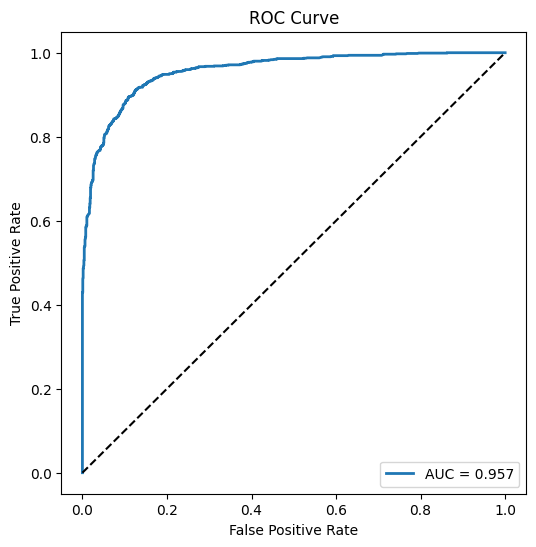

In [30]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9614319627333863


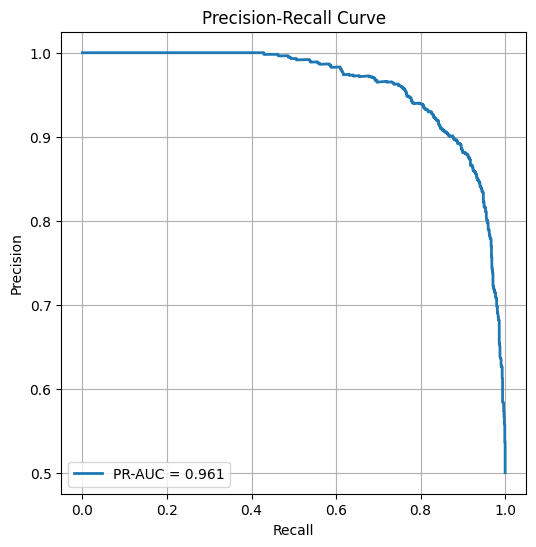

In [38]:
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

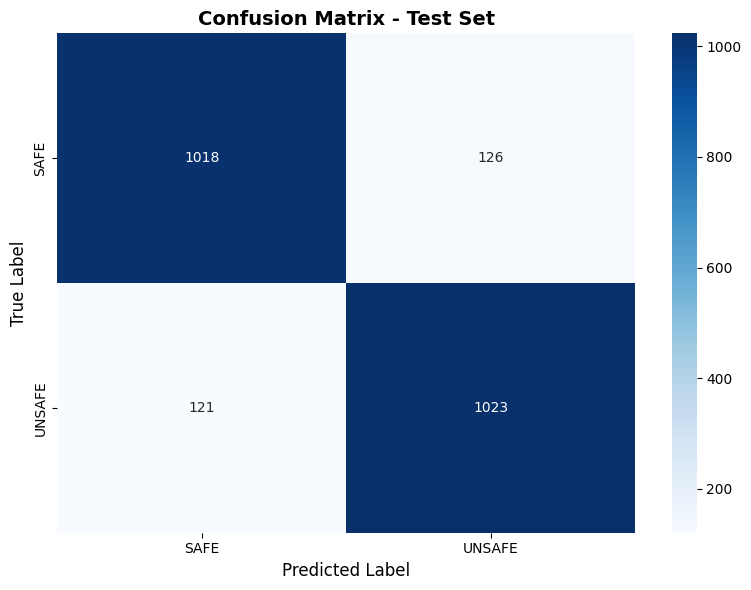

In [39]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

#### Save Model and Test

In [33]:
# Save the version currently in the trainer's brain
trainer.save_model("./my_final_bert")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


In [34]:
# TEST MODEL

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# Load the model and tokenizer from your local folder
path = "./my_final_bert"
model = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # Ensure you saved the tokenizer there too!

# Create a 'pipeline' (the easiest way to use the model)
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3258.91it/s]


In [35]:
# Test it on a new sentence
result = classifier("kiss it from my lips")
print(result)

[{'label': 'LABEL_0', 'score': 0.7049626111984253}]


In [36]:
import accelerate
import transformers
import torch

print(f"Accelerate version: {accelerate.__version__}")
print(f"Transformers version: {transformers.__version__}")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Accelerate version: 1.13.0
Transformers version: 5.3.0
Torch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
